# Spinoff Index Arbitrage — EDA

**Strategy (README):**
- **Entry:** Short the spin-off at first trading day close when forced-flow signals trigger
- **Hedge:** Long S&P 500 futures — beta-neutral
- **Exit:** Child added to S&P 500, rebalance date, 21–60 day time-stop, or stop-loss
- **Sizing:** Forced-flow intensity + deletion probability model

**Focus of this notebook:** the spinoff **child** — the actual short leg.
When a parent spins off a subsidiary not in the S&P 500, passive funds mechanically
dump the shares they receive. We are trying to measure and exploit that pressure.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RAW_DIR   = Path('data/raw')
CLEAN_DIR = Path('data/clean')

## 1. Load Data

In [2]:
events = pd.read_csv(
    CLEAN_DIR / 'spinoff_events_merged.csv',
    parse_dates=['announce_date', 'effective_date', 'sp500_start', 'sp500_end']
)

# Spinoff child daily OHLCV (the short leg)
children = pd.read_parquet(RAW_DIR / 'spinoff_children_crsp.parquet')

# Child S&P 500 membership — key for exit signal
child_sp500 = pd.read_parquet(RAW_DIR / 'spinoff_children_sp500.parquet')

# S&P 500 daily returns for market-adjustment
idx_ret = pd.read_parquet(RAW_DIR / 'crsp_index_returns.parquet')

# S&P 500 constituent history (for deletion signal)
constituents = pd.read_parquet(RAW_DIR / 'sp500_constituents_pit.parquet')

# Passive AUM
passive_aum = (pd.read_parquet(RAW_DIR / 'sp500_passive_aum.parquet')
               if (RAW_DIR / 'sp500_passive_aum.parquet').exists() else None)

# Parent CRSP prices (large file — gitignored, may not exist)
crsp_path = RAW_DIR / 'crsp_daily.parquet'
crsp = pd.read_parquet(crsp_path) if crsp_path.exists() else None

print(f'Events:              {len(events)} spinoff events  '
      f'({events["effective_date"].min().year}–{events["effective_date"].max().year})')
print(f'Children CRSP:       {len(children):,} rows, {children["permno"].nunique()} children')
print(f'Child SP500 records: {len(child_sp500)} children ever in S&P 500')
if passive_aum is not None:
    lat = passive_aum.sort_values('date').iloc[-1]
    print(f'Passive AUM:         ${lat["total_aum_billions"]:.0f}B ({lat["date"].date()})')
if crsp is None:
    print('[!] crsp_daily.parquet not found — parent event study skipped (run repull_data.py)')

Events:              30 spinoff events  (2020–2025)
Children CRSP:       17,945 rows, 24 children
Child SP500 records: 14 children ever in S&P 500
Passive AUM:         $4401B (2026-03-31)


## 2. Events Overview & Child Classification

The critical question for the short trade: **is the spinoff child in the S&P 500?**

- **Excluded** — passive funds must SELL the child shares they receive → forced selling pressure → short works
- **Immediately included** — passive funds must BUY the child to match new index weight → forced buying → short doesn't work

In [3]:
# Classify each child by S&P 500 inclusion timing
first_inc = (
    child_sp500.sort_values('added_date')
    .groupby('child_ticker', as_index=False)
    .first()
    [['child_ticker', 'added_date', 'removed_date']]
)

eff_dates = events[['spinoff_ticker', 'effective_date']].rename(columns={'spinoff_ticker': 'child_ticker'})
first_inc = first_inc.merge(eff_dates, on='child_ticker', how='left')
first_inc['days_to_inclusion'] = (first_inc['added_date'] - first_inc['effective_date']).dt.days

def classify(row):
    if pd.isna(row['days_to_inclusion']):
        return 'excluded'
    return 'immediately included' if row['days_to_inclusion'] <= 5 else 'later included'

first_inc['inclusion_status'] = first_inc.apply(classify, axis=1)
status_map = first_inc.set_index('child_ticker')['inclusion_status'].to_dict()

# Attach to events
events['inclusion_status'] = events['spinoff_ticker'].map(status_map).fillna('excluded')

COLOR_MAP = {
    'excluded':             '#d32f2f',
    'immediately included': '#1976d2',
    'later included':       '#f57c00',
}

In [4]:
disp = events[[
    'parent_ticker', 'spinoff_ticker', 'effective_date',
    'parent_index_weight', 'forced_flow_adv', 'inclusion_status'
]].copy()
disp['effective_date']       = disp['effective_date'].dt.strftime('%Y-%m-%d')
disp['parent_index_weight']  = (disp['parent_index_weight'] * 100).map('{:.3f}%'.format)
disp['forced_flow_adv']      = disp['forced_flow_adv'].map(
    lambda x: f'{x:.1f}×' if pd.notna(x) else 'N/A'
)
disp.columns = ['Parent', 'Child', 'Effective Date', 'Index Wt', 'Flow/ADV', 'SP500 Status']
display(disp)

,Parent,Child,Effective Date,Index Wt,Flow/ADV,SP500 Status
0,MCK,1784039D,2020-03-10,0.080%,7.7×,excluded
1,HWM,ARNC,2020-04-01,0.001%,6.7×,excluded
2,RTX,CARR,2020-04-03,0.087%,4.2×,immediately included
3,RTX,OTIS,2020-04-03,0.087%,4.2×,immediately included
4,ECL,1695496D,2020-06-04,0.228%,2.7×,excluded
5,OXY,OXY/WS,2020-07-02,0.056%,1.0×,excluded
6,FTV,VNT,2020-10-09,0.088%,5.7×,immediately included
7,PFE,VTRS,2020-11-17,0.629%,7.1×,immediately included
8,MRK,OGN,2021-06-03,0.496%,11.5×,immediately included
9,DTE,DTM,2021-07-01,0.063%,9.3×,excluded


In [5]:
inc_counts = events['inclusion_status'].value_counts()
print('Child S&P 500 status at spinoff:')
for status, count in inc_counts.items():
    print(f'  {status:<25s}: {count:2d} ({count/len(events):.0%})')
print()
print('→ Excluded children are the pure forced-selling candidates for the short trade.')
print('→ Immediately-included children face passive BUYING — not appropriate to short.')

Child S&P 500 status at spinoff:
  excluded                 : 17 (57%)
  immediately included     : 13 (43%)

→ Excluded children are the pure forced-selling candidates for the short trade.
→ Immediately-included children face passive BUYING — not appropriate to short.


## 3. Spinoff Child Price Paths — First 90 Trading Days

Normalized price = 100 on effective date (t=0). Excludes OXY warrants + 4 future 2025 events.

In [6]:
def build_child_window(permno, eff_date, crsp_df, idx_df, post=90):
    """Market-adjusted return path for one spinoff child from t=0."""
    child = crsp_df[crsp_df['permno'] == int(permno)].sort_values('date').copy()
    valid = child[child['date'] >= eff_date]
    if len(valid) == 0:
        return pd.DataFrame()
    window = valid.head(post + 1).copy()
    window = window.merge(idx_df[['date', 'sprtrn']], on='date', how='left')
    window['t'] = range(len(window))
    # Use adjusted price; fall back to abs(prc) if adj_prc is null
    prc_col = 'adj_prc' if 'adj_prc' in window.columns else 'prc'
    t0 = window.iloc[0][prc_col]
    if pd.isna(t0) or t0 == 0:
        t0 = window.iloc[0]['prc'].abs()
    window['norm_prc']    = window[prc_col] / t0 * 100
    window['ret_mkt_adj'] = window['ret'] - window['sprtrn']
    window['car']         = window['ret_mkt_adj'].cumsum()
    window['short_pnl']   = -window['car']   # P&L of being short the child vs market
    # Normalized volume: relative to average of days 5-30
    vol_base = window[window['t'].between(5, 30)]['dollar_vol'].mean()
    window['norm_vol'] = window['dollar_vol'] / vol_base if vol_base > 0 else np.nan
    return window


child_windows = []
for _, ev in events.iterrows():
    child_rows = children[children['child_ticker'] == ev['spinoff_ticker']]
    if child_rows.empty:
        continue
    permno = child_rows['permno'].iloc[0]
    w = build_child_window(permno, ev['effective_date'], children, idx_ret, post=90)
    if len(w) == 0:
        continue
    w['child_ticker']     = ev['spinoff_ticker']
    w['parent_ticker']    = ev['parent_ticker']
    w['effective_date']   = ev['effective_date']
    w['inclusion_status'] = ev['inclusion_status']
    w['forced_flow_adv']  = ev.get('forced_flow_adv', np.nan)
    child_windows.append(w)

all_cw = pd.concat(child_windows, ignore_index=True) if child_windows else pd.DataFrame()
print(f'Child event windows: {all_cw["child_ticker"].nunique()} children, '
      f'{len(all_cw):,} rows')

Child event windows: 21 children, 1,885 rows


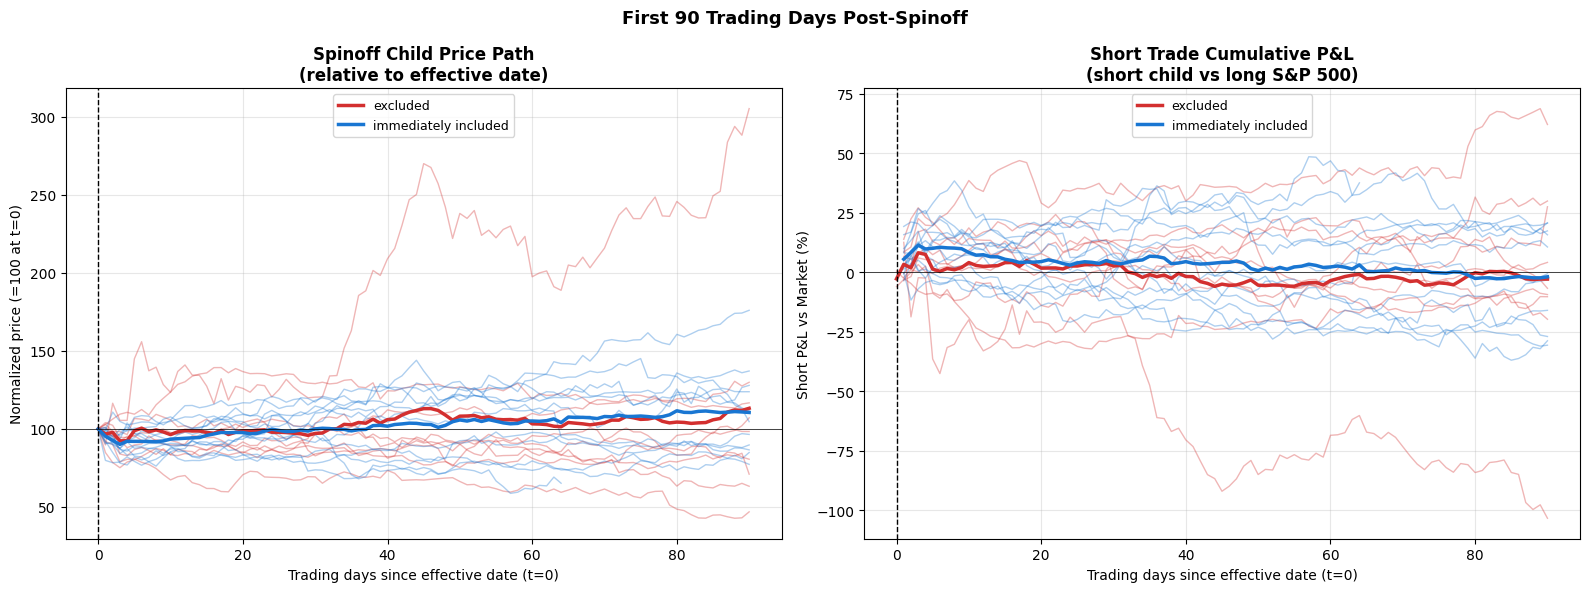

In [7]:
# Individual price paths — one line per child, colored by inclusion status
if len(all_cw):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for status, grp in all_cw.groupby('inclusion_status'):
        color  = COLOR_MAP.get(status, 'grey')
        label  = status
        for ticker, tgrp in grp.groupby('child_ticker'):
            axes[0].plot(tgrp['t'], tgrp['norm_prc'],
                         color=color, alpha=0.35, lw=1)
            axes[1].plot(tgrp['t'], tgrp['short_pnl'] * 100,
                         color=color, alpha=0.35, lw=1)

    # Bold averages per status group
    for status, grp in all_cw.groupby('inclusion_status'):
        color = COLOR_MAP.get(status, 'grey')
        avg_prc = grp.groupby('t')['norm_prc'].mean()
        avg_pnl = grp.groupby('t')['short_pnl'].mean()
        axes[0].plot(avg_prc.index, avg_prc.values, color=color, lw=2.5, label=status)
        axes[1].plot(avg_pnl.index, avg_pnl.values * 100, color=color, lw=2.5, label=status)

    for ax in axes:
        ax.axvline(0, color='black', linestyle='--', lw=1)
        ax.axhline(100 if ax == axes[0] else 0, color='black', lw=0.5)
        ax.set_xlabel('Trading days since effective date (t=0)')
        ax.legend(fontsize=9)

    axes[0].set_ylabel('Normalized price (=100 at t=0)')
    axes[0].set_title('Spinoff Child Price Path\n(relative to effective date)', fontweight='bold')
    axes[1].set_ylabel('Short P&L vs Market (%)')
    axes[1].set_title('Short Trade Cumulative P&L\n(short child vs long S&P 500)', fontweight='bold')

    plt.suptitle('First 90 Trading Days Post-Spinoff', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Child Return Analysis — Excluded vs Included

Compute CAR at 5, 10, 21, 42, 63 trading days for each child.
Test if excluded children systematically underperform (supporting the short trade).

In [8]:
if len(all_cw):
    horizons = [5, 10, 21, 42, 63]
    car_rows = []
    for _, ev in events.iterrows():
        ticker = ev['spinoff_ticker']
        grp = all_cw[all_cw['child_ticker'] == ticker]
        if grp.empty:
            continue
        row = {'child_ticker': ticker, 'parent_ticker': ev['parent_ticker'],
               'inclusion_status': ev['inclusion_status'],
               'forced_flow_adv': ev.get('forced_flow_adv', np.nan)}
        for h in horizons:
            sub = grp[grp['t'] == h]
            row[f'car_{h}d'] = sub['car'].values[0] if len(sub) else np.nan
            row[f'short_pnl_{h}d'] = sub['short_pnl'].values[0] if len(sub) else np.nan
        car_rows.append(row)

    car_df = pd.DataFrame(car_rows)

    print('=== Average Short P&L (market-adjusted) by inclusion status ===')
    for status in ['excluded', 'immediately included', 'later included']:
        sub = car_df[car_df['inclusion_status'] == status]
        if len(sub) == 0:
            continue
        print(f'\n  {status.upper()} (n={len(sub)}):')
        for h in horizons:
            col = f'short_pnl_{h}d'
            vals = sub[col].dropna()
            if len(vals) == 0:
                continue
            t_stat, p_val = stats.ttest_1samp(vals, 0)
            print(f'    t={h:2d}d:  mean={vals.mean()*100:+.2f}%  '
                  f'std={vals.std()*100:.2f}%  '
                  f't={t_stat:.2f}  p={p_val:.3f}  n={len(vals)}')

=== Average Short P&L (market-adjusted) by inclusion status ===

  EXCLUDED (n=9):
    t= 5d:  mean=+1.30%  std=17.79%  t=0.22  p=0.832  n=9
    t=10d:  mean=+4.05%  std=18.85%  t=0.64  p=0.537  n=9
    t=21d:  mean=+1.78%  std=19.84%  t=0.27  p=0.795  n=9
    t=42d:  mean=-3.96%  std=32.62%  t=-0.36  p=0.725  n=9
    t=63d:  mean=-1.25%  std=29.14%  t=-0.13  p=0.901  n=9

  IMMEDIATELY INCLUDED (n=13):
    t= 5d:  mean=+10.77%  std=10.36%  t=3.75  p=0.003  n=13
    t=10d:  mean=+8.54%  std=9.86%  t=3.12  p=0.009  n=13
    t=21d:  mean=+5.03%  std=11.68%  t=1.55  p=0.146  n=13
    t=42d:  mean=+5.35%  std=19.38%  t=1.00  p=0.339  n=13
    t=63d:  mean=+3.72%  std=21.67%  t=0.62  p=0.548  n=13


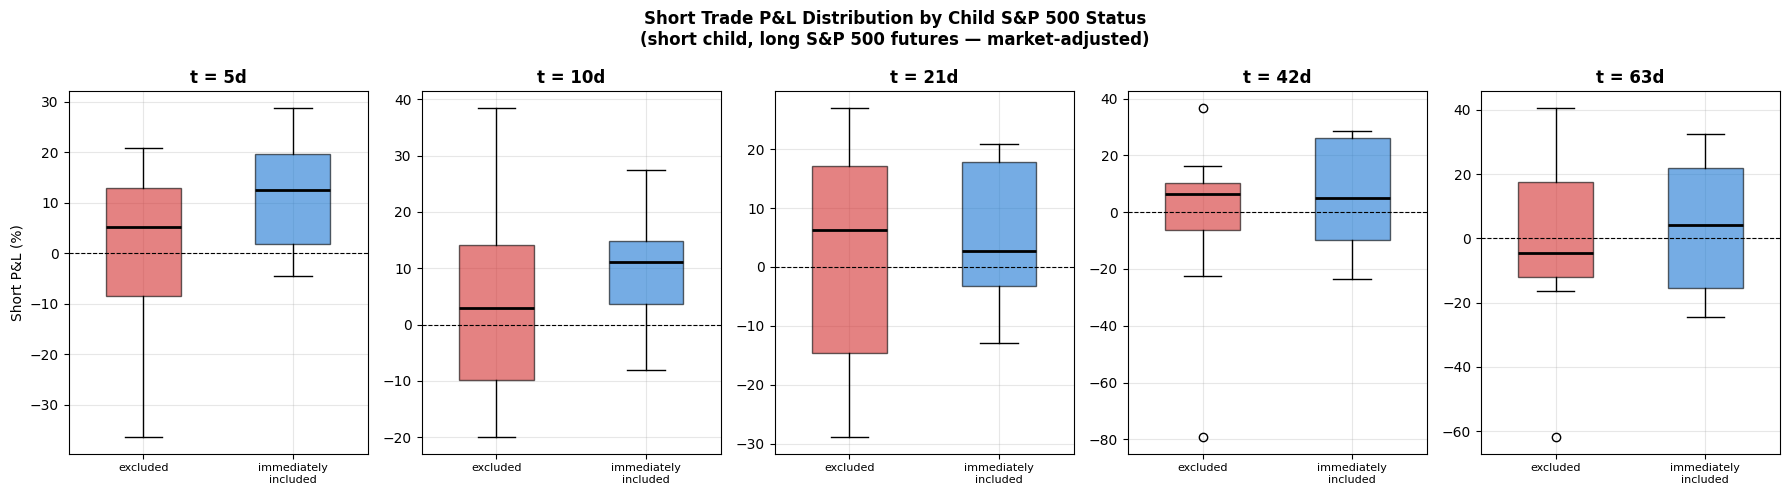

In [9]:
if len(all_cw):
    fig, axes = plt.subplots(1, len(horizons), figsize=(18, 5), sharey=False)
    for ax, h in zip(axes, horizons):
        col = f'short_pnl_{h}d'
        data_by_status = {
            st: car_df[car_df['inclusion_status'] == st][col].dropna() * 100
            for st in COLOR_MAP
            if len(car_df[car_df['inclusion_status'] == st][col].dropna()) > 0
        }
        positions = list(range(len(data_by_status)))
        labels    = list(data_by_status.keys())
        colors    = [COLOR_MAP[s] for s in labels]

        bp = ax.boxplot([data_by_status[s] for s in labels],
                        positions=positions, patch_artist=True, widths=0.5)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        for median in bp['medians']:
            median.set(color='black', linewidth=2)

        ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.set_xticks(positions)
        ax.set_xticklabels([s.replace(' ', '\n') for s in labels], fontsize=8)
        ax.set_title(f't = {h}d', fontweight='bold')
        ax.set_ylabel('Short P&L (%)' if h == horizons[0] else '')

    plt.suptitle('Short Trade P&L Distribution by Child S&P 500 Status\n'
                 '(short child, long S&P 500 futures — market-adjusted)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [10]:
# Statistical test: excluded vs immediately included at 21-day horizon
if len(all_cw) and 'short_pnl_21d' in car_df.columns:
    excl = car_df[car_df['inclusion_status'] == 'excluded']['short_pnl_21d'].dropna()
    incl = car_df[car_df['inclusion_status'] == 'immediately included']['short_pnl_21d'].dropna()
    print('=== Two-sample t-test: excluded vs immediately included at t=21d ===')
    if len(excl) > 1 and len(incl) > 1:
        t_stat, p_val = stats.ttest_ind(excl, incl)
        print(f'  Excluded (n={len(excl)}):          mean = {excl.mean()*100:+.2f}%')
        print(f'  Immediately included (n={len(incl)}):  mean = {incl.mean()*100:+.2f}%')
        print(f'  Difference:                 {(excl.mean()-incl.mean())*100:+.2f}%')
        print(f'  t-statistic: {t_stat:.2f}   p-value: {p_val:.3f}')
        print(f'  Significant: {"YES" if p_val < 0.05 else "NO"} (α=0.05)')
    else:
        print('  Not enough data for two-sample test')

=== Two-sample t-test: excluded vs immediately included at t=21d ===
  Excluded (n=9):          mean = +1.78%
  Immediately included (n=13):  mean = +5.03%
  Difference:                 -3.25%
  t-statistic: -0.49   p-value: 0.633
  Significant: NO (α=0.05)


## 5. Volume & Liquidity Around Spinoff

Forced selling creates abnormal volume and potentially widens bid-ask spreads.
Volume spike at t=0 is consistent with passive rebalancing flows.

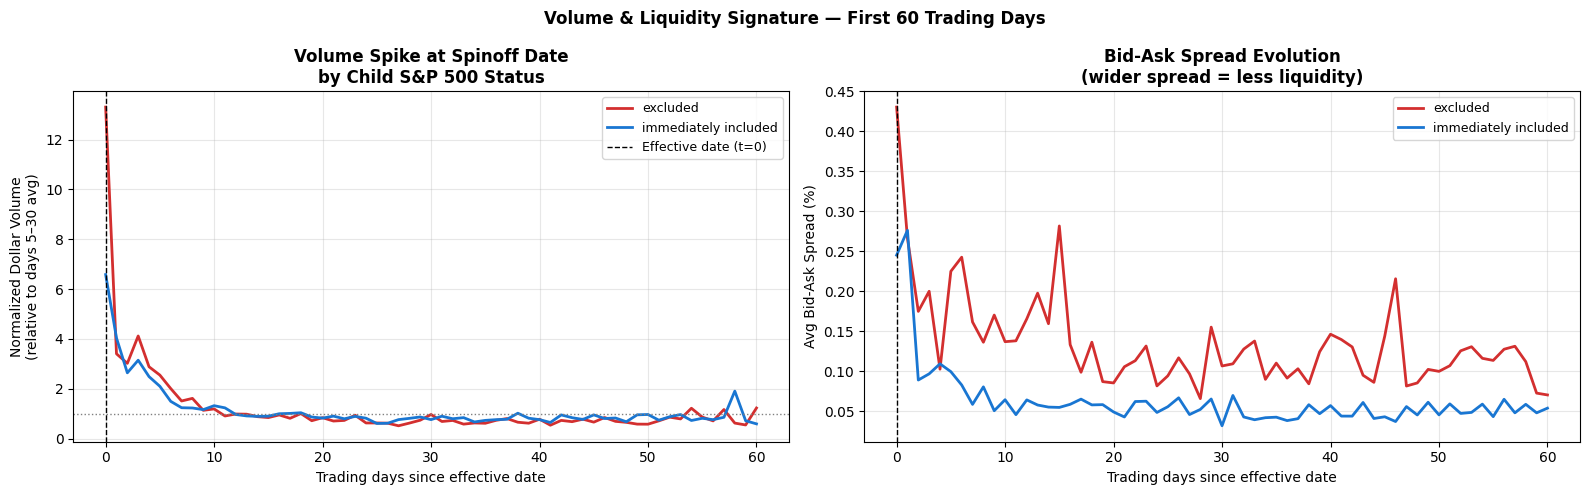

In [11]:
if len(all_cw):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Panel 1: Average normalized volume for excluded vs included
    vol_by_status = (
        all_cw[all_cw['t'].between(0, 60)]
        .groupby(['inclusion_status', 't'])['norm_vol']
        .mean()
        .reset_index()
    )

    for status, grp in vol_by_status.groupby('inclusion_status'):
        color = COLOR_MAP.get(status, 'grey')
        axes[0].plot(grp['t'], grp['norm_vol'], color=color, lw=2, label=status)

    axes[0].axvline(0, color='black', linestyle='--', lw=1, label='Effective date (t=0)')
    axes[0].axhline(1, color='grey', linestyle=':', lw=1)
    axes[0].set_xlabel('Trading days since effective date')
    axes[0].set_ylabel('Normalized Dollar Volume\n(relative to days 5–30 avg)')
    axes[0].set_title('Volume Spike at Spinoff Date\nby Child S&P 500 Status', fontweight='bold')
    axes[0].legend(fontsize=9)

    # Panel 2: Bid-ask spread evolution (proxy for liquidity stress)
    spread_by_status = (
        all_cw[all_cw['t'].between(0, 60)]
        .groupby(['inclusion_status', 't'])['spread_pct']
        .mean()
        .reset_index()
    )

    for status, grp in spread_by_status.groupby('inclusion_status'):
        color = COLOR_MAP.get(status, 'grey')
        axes[1].plot(grp['t'], grp['spread_pct'] * 100, color=color, lw=2, label=status)

    axes[1].axvline(0, color='black', linestyle='--', lw=1)
    axes[1].set_xlabel('Trading days since effective date')
    axes[1].set_ylabel('Avg Bid-Ask Spread (%)')
    axes[1].set_title('Bid-Ask Spread Evolution\n(wider spread = less liquidity)', fontweight='bold')
    axes[1].legend(fontsize=9)

    plt.suptitle('Volume & Liquidity Signature — First 60 Trading Days',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [12]:
if len(all_cw):
    # Volume at t=0 vs t=1 vs baseline (days 5-30)
    vol_summary = (
        all_cw[all_cw['t'].isin([0, 1, 5, 10, 20, 30])]
        .groupby(['inclusion_status', 't'])['norm_vol']
        .agg(['mean', 'median', 'count'])
        .round(2)
    )
    print('Normalized volume by trading day (1.0 = avg of days 5-30):')
    print(vol_summary.to_string())

Normalized volume by trading day (1.0 = avg of days 5-30):
                          mean  median  count
inclusion_status     t                       
excluded             0  13.300  15.690      9
                     1   3.400   3.750      9
                     5   2.550   2.810      9
                     10  1.190   1.010      9
                     20  0.840   0.790      9
                     30  0.970   0.820      9
immediately included 0   6.580   6.000     12
                     1   4.040   2.560     12
                     5   2.100   1.950     12
                     10  1.320   1.280     12
                     20  0.820   0.750     12
                     30  0.760   0.760     12


## 6. Forced-Flow Feature

$$\text{Forced Flow (ADV)} = \frac{\text{Passive AUM} \times w_{\text{parent}}}{\text{Child 30-day ADV}}$$

This measures how many days of average trading volume passive funds need to sell.
Higher = more selling pressure = stronger short signal.

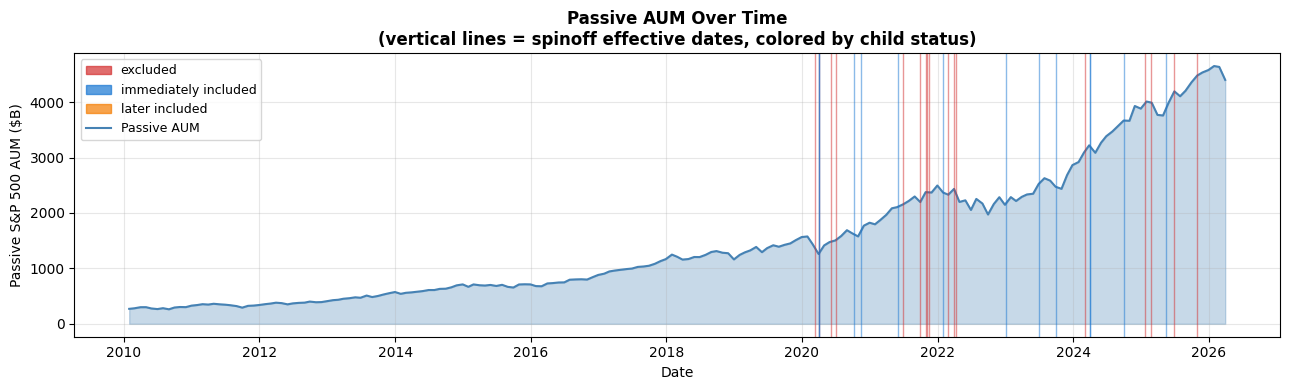

In [13]:
if passive_aum is not None:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.fill_between(passive_aum['date'], passive_aum['total_aum_billions'],
                    alpha=0.3, color='steelblue')
    ax.plot(passive_aum['date'], passive_aum['total_aum_billions'],
            color='steelblue', lw=1.5, label='Total passive AUM')
    for _, ev in events.iterrows():
        color = COLOR_MAP.get(ev['inclusion_status'], 'grey')
        ax.axvline(ev['effective_date'], color=color, alpha=0.5, lw=1)
    # Legend patches
    from matplotlib.patches import Patch
    handles = [Patch(color=c, alpha=0.7, label=s) for s, c in COLOR_MAP.items()]
    ax.legend(handles=handles + [plt.Line2D([0],[0], color='steelblue', label='Passive AUM')],
              fontsize=9)
    ax.set_xlabel('Date')
    ax.set_ylabel('Passive S&P 500 AUM ($B)')
    ax.set_title('Passive AUM Over Time\n(vertical lines = spinoff effective dates, colored by child status)',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

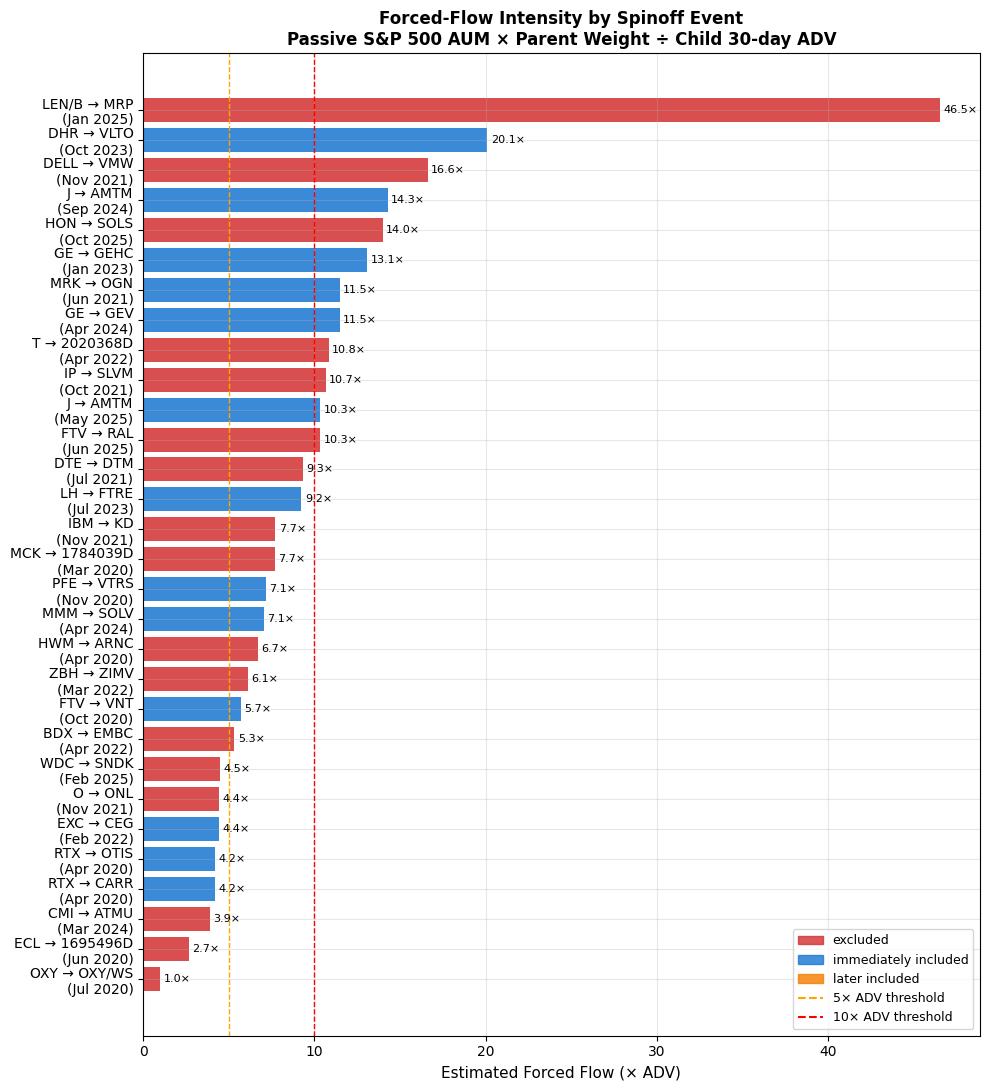

Events >10× ADV: 12 / 30
Events >5× ADV:  22 / 30


In [14]:
if 'forced_flow_adv' in events.columns:
    ff = events[['parent_ticker', 'spinoff_ticker', 'effective_date',
                  'forced_flow_adv', 'forced_flow_usd', 'inclusion_status']].copy()
    ff = ff.dropna(subset=['forced_flow_adv']).sort_values('forced_flow_adv')
    ff['label'] = (ff['parent_ticker'] + ' → ' + ff['spinoff_ticker'].fillna('?')
                   + '\n(' + ff['effective_date'].dt.strftime('%b %Y') + ')')
    colors = [COLOR_MAP.get(s, 'grey') for s in ff['inclusion_status']]

    fig, ax = plt.subplots(figsize=(10, 11))
    bars = ax.barh(ff['label'], ff['forced_flow_adv'], color=colors, alpha=0.85)
    ax.axvline(5,  color='orange', linestyle='--', lw=1, label='5× ADV')
    ax.axvline(10, color='red',    linestyle='--', lw=1, label='10× ADV')
    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, alpha=0.8, label=s) for s, c in COLOR_MAP.items()]
    ax.legend(handles=legend_handles + [
        plt.Line2D([0],[0], color='orange', linestyle='--', label='5× ADV threshold'),
        plt.Line2D([0],[0], color='red',    linestyle='--', label='10× ADV threshold'),
    ], fontsize=9)
    for bar, val in zip(bars, ff['forced_flow_adv']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}×', va='center', fontsize=8)
    ax.set_xlabel('Estimated Forced Flow (× ADV)', fontsize=11)
    ax.set_title('Forced-Flow Intensity by Spinoff Event\n'
                 'Passive S&P 500 AUM × Parent Weight ÷ Child 30-day ADV',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f'Events >10× ADV: {(ff["forced_flow_adv"] >= 10).sum()} / {len(ff)}')
    print(f'Events >5× ADV:  {(ff["forced_flow_adv"] >= 5).sum()} / {len(ff)}')

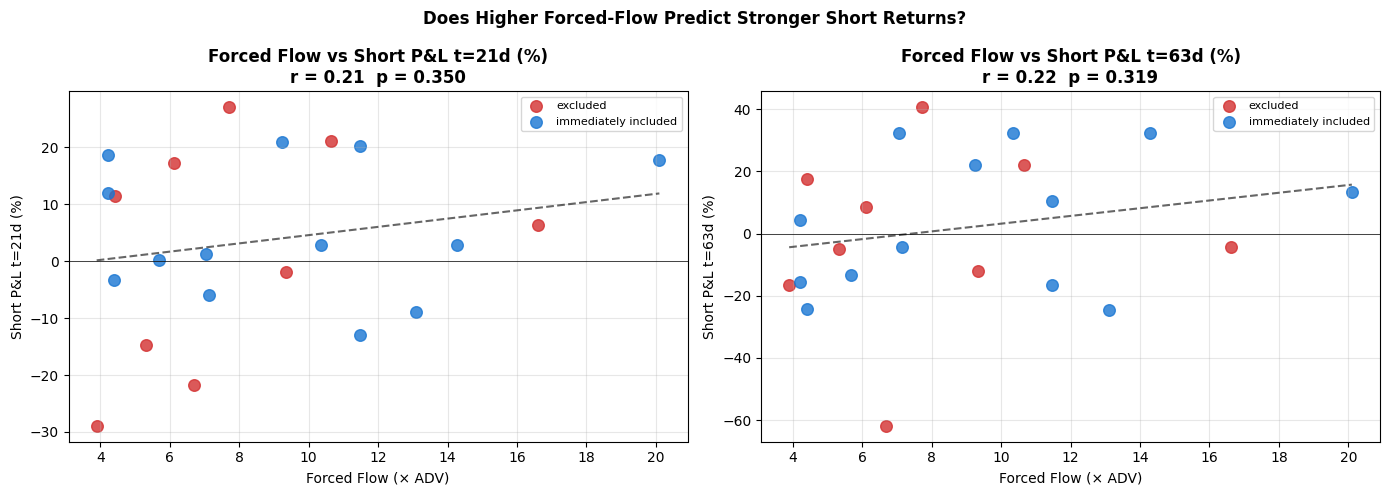

In [15]:
# Forced-flow vs short P&L — does more forced flow predict better short returns?
if len(all_cw) and 'forced_flow_adv' in events.columns:
    ff_vs_ret = car_df[['child_ticker', 'forced_flow_adv',
                         'short_pnl_21d', 'short_pnl_63d',
                         'inclusion_status']].dropna(subset=['forced_flow_adv'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, label in zip(axes,
        ['short_pnl_21d', 'short_pnl_63d'],
        ['Short P&L t=21d (%)', 'Short P&L t=63d (%)']):
        valid = ff_vs_ret.dropna(subset=[col])
        for status, grp in valid.groupby('inclusion_status'):
            ax.scatter(grp['forced_flow_adv'], grp[col] * 100,
                       color=COLOR_MAP.get(status, 'grey'), label=status, alpha=0.8, s=70)
        if len(valid) > 2:
            m, b = np.polyfit(valid['forced_flow_adv'], valid[col] * 100, 1)
            x_  = np.linspace(valid['forced_flow_adv'].min(), valid['forced_flow_adv'].max(), 50)
            ax.plot(x_, m*x_ + b, 'k--', alpha=0.6)
            r, p = stats.pearsonr(valid['forced_flow_adv'], valid[col])
            ax.set_title(f'Forced Flow vs {label}\nr = {r:.2f}  p = {p:.3f}',
                         fontweight='bold')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_xlabel('Forced Flow (× ADV)')
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
    plt.suptitle('Does Higher Forced-Flow Predict Stronger Short Returns?',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

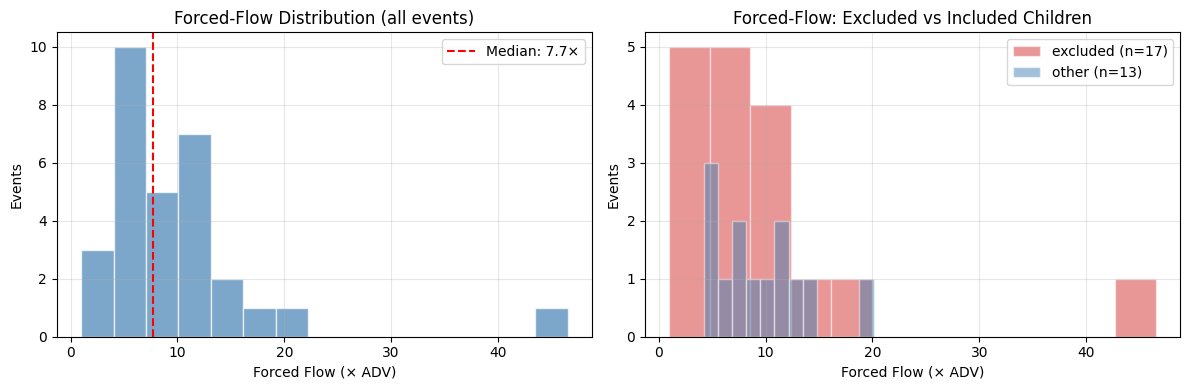

In [16]:
# Distribution of forced-flow (raw signal)
if 'forced_flow_adv' in events.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    events['ff_adv_excl'] = np.where(events['inclusion_status'] == 'excluded',
                                      events['forced_flow_adv'], np.nan)
    events['ff_adv_incl'] = np.where(events['inclusion_status'] != 'excluded',
                                      events['forced_flow_adv'], np.nan)
    axes[0].hist(events['forced_flow_adv'].dropna(), bins=15, color='steelblue',
                 edgecolor='white', alpha=0.7)
    axes[0].axvline(events['forced_flow_adv'].median(), color='red', linestyle='--',
                    label=f'Median: {events["forced_flow_adv"].median():.1f}×')
    axes[0].set_xlabel('Forced Flow (× ADV)')
    axes[0].set_ylabel('Events')
    axes[0].set_title('Forced-Flow Distribution (all events)')
    axes[0].legend()

    for status, col_name in [('excluded', 'ff_adv_excl'), ('other', 'ff_adv_incl')]:
        vals = events[col_name].dropna()
        axes[1].hist(vals, bins=12, alpha=0.5,
                     color=COLOR_MAP.get(status, 'steelblue'), edgecolor='white',
                     label=f'{status} (n={len(vals)})')
    axes[1].set_xlabel('Forced Flow (× ADV)')
    axes[1].set_ylabel('Events')
    axes[1].set_title('Forced-Flow: Excluded vs Included Children')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 7. Individual Child Return Profiles

Heatmap of market-adjusted cumulative returns for each child over the first 63 days.
Red = child underperforms market (good for short), green = outperforms (bad for short).

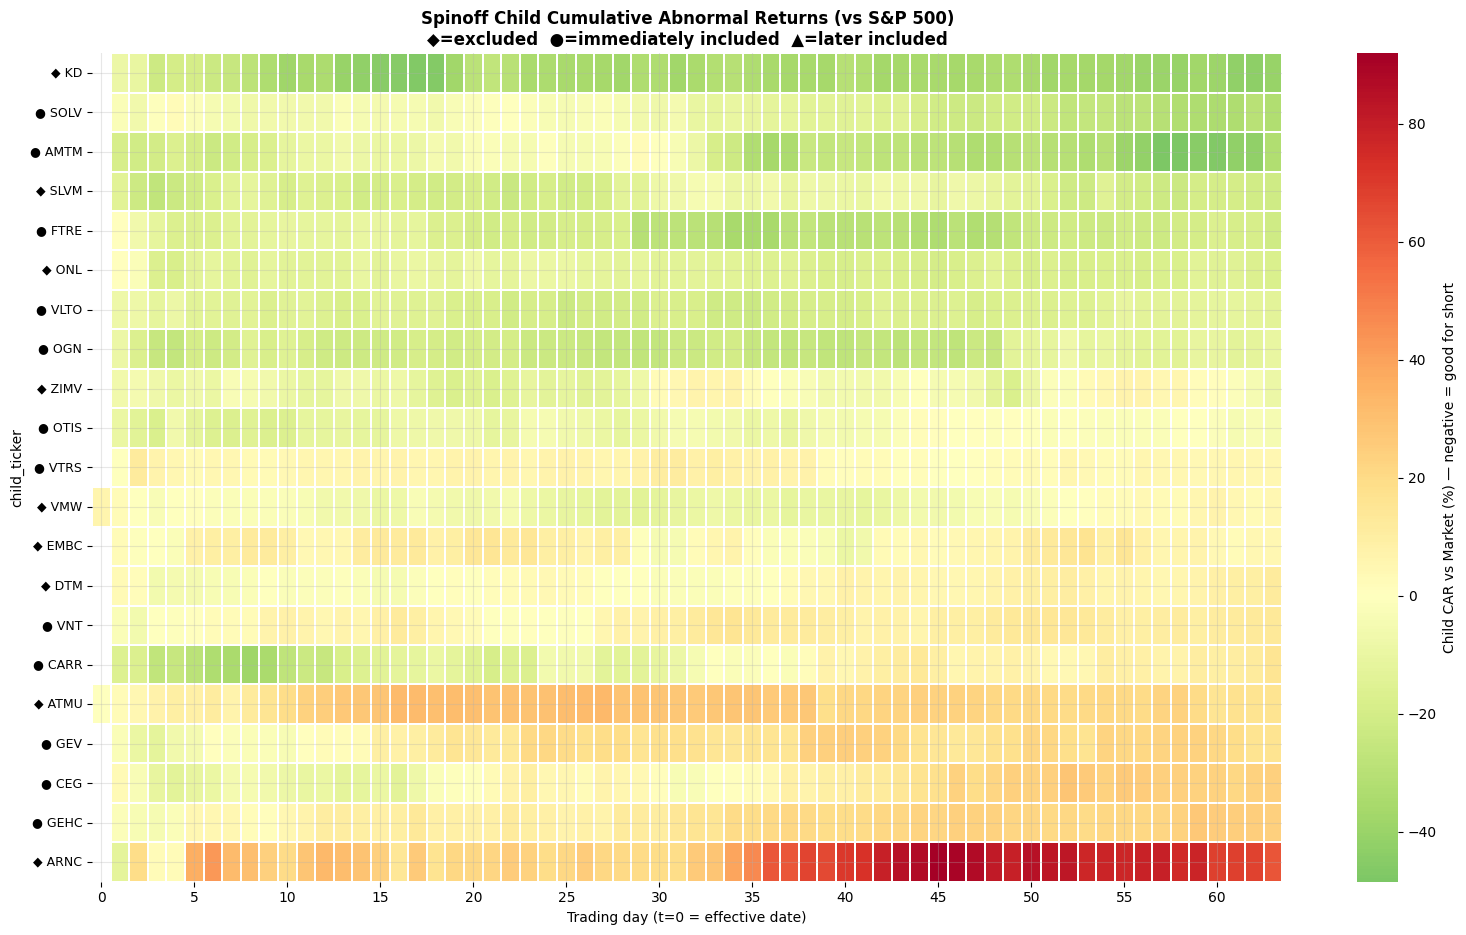

In [17]:
if len(all_cw):
    car_matrix = (
        all_cw[all_cw['t'].between(0, 63)]
        .pivot_table(index='child_ticker', columns='t', values='car', aggfunc='mean')
    )
    # Sort: worst performers (best for short) at top
    car_matrix = car_matrix.sort_values(63 if 63 in car_matrix.columns else car_matrix.columns[-1])

    fig, ax = plt.subplots(figsize=(16, max(6, len(car_matrix) * 0.45)))
    im = sns.heatmap(
        car_matrix * 100, center=0, cmap='RdYlGn_r',
        ax=ax, xticklabels=5, linewidths=0.1,
        cbar_kws={'label': 'Child CAR vs Market (%) — negative = good for short'}
    )
    # Annotate rows with inclusion status
    ytick_labels = []
    for ticker in car_matrix.index:
        status = status_map.get(ticker, 'excluded')
        marker = '◆' if status == 'excluded' else ('●' if status == 'immediately included' else '▲')
        ytick_labels.append(f'{marker} {ticker}')
    ax.set_yticklabels(ytick_labels, fontsize=9)
    ax.set_xlabel('Trading day (t=0 = effective date)')
    ax.set_title('Spinoff Child Cumulative Abnormal Returns (vs S&P 500)\n'
                 '◆=excluded  ●=immediately included  ▲=later included',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Parent Event Study (Condensed)

Brief look at parent behavior around the spinoff date — informative for timing entry.

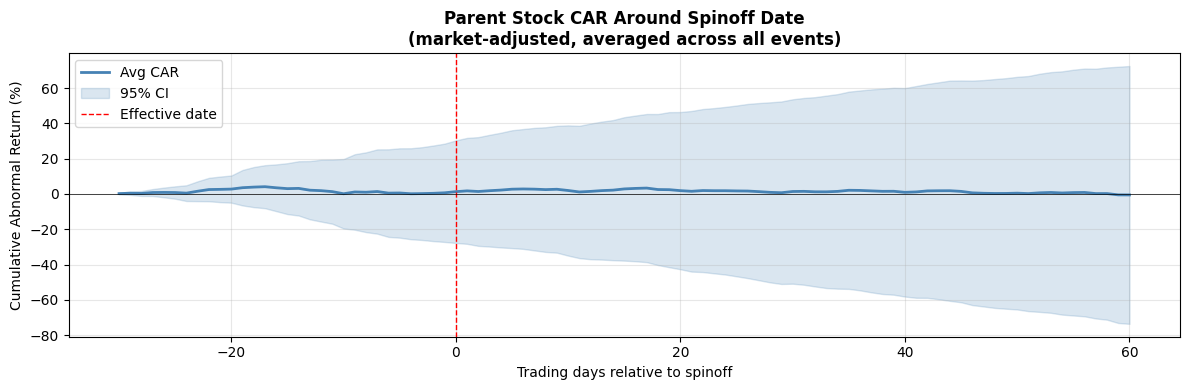

Parent CAR[+1,+21]: mean=+0.22%  t=0.11  p=0.911


In [18]:
if crsp is not None:
    def get_parent_window(permno, eff_date, crsp_df, idx_df, pre=30, post=60):
        parent = crsp_df[crsp_df['permno'] == int(permno)].copy()
        cal = int((pre + post) * 1.6)
        window = parent[
            (parent['date'] >= eff_date - pd.Timedelta(days=cal)) &
            (parent['date'] <= eff_date + pd.Timedelta(days=cal))
        ].merge(idx_df[['date', 'sprtrn']], on='date', how='left').sort_values('date')
        window = window.reset_index(drop=True)
        eff_idx = window['date'].searchsorted(eff_date)
        window['t'] = range(-eff_idx, len(window) - eff_idx)
        window['ret_mkt_adj'] = window['ret'] - window['sprtrn']
        return window[window['t'].between(-pre, post)]

    parent_windows = []
    for _, ev in events[events['permno'].notna()].iterrows():
        w = get_parent_window(ev['permno'], ev['effective_date'], crsp, idx_ret)
        if len(w) == 0:
            continue
        w['parent_ticker']  = ev['parent_ticker']
        w['effective_date'] = ev['effective_date']
        parent_windows.append(w)

    if parent_windows:
        all_pw = pd.concat(parent_windows, ignore_index=True)
        avg_car = all_pw.groupby('t')['ret_mkt_adj'].agg(['mean', 'sem']).reset_index()
        avg_car['cum_mean'] = avg_car['mean'].cumsum()
        ci = 1.96 * avg_car['sem'].cumsum()

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(avg_car['t'], avg_car['cum_mean'] * 100, lw=2, color='steelblue', label='Avg CAR')
        ax.fill_between(avg_car['t'],
                        (avg_car['cum_mean'] - ci) * 100,
                        (avg_car['cum_mean'] + ci) * 100,
                        alpha=0.2, color='steelblue', label='95% CI')
        ax.axvline(0, color='red', linestyle='--', lw=1, label='Effective date')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_xlabel('Trading days relative to spinoff')
        ax.set_ylabel('Cumulative Abnormal Return (%)')
        ax.set_title('Parent Stock CAR Around Spinoff Date\n'
                     '(market-adjusted, averaged across all events)',
                     fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.show()

        post = all_pw[all_pw['t'].between(1, 21)].groupby(['parent_ticker','effective_date'])['ret_mkt_adj'].sum()
        t1, p1 = stats.ttest_1samp(post.dropna(), 0)
        print(f'Parent CAR[+1,+21]: mean={post.mean()*100:+.2f}%  t={t1:.2f}  p={p1:.3f}')
    else:
        print('[!] No parent event windows built')
else:
    print('[!] crsp_daily.parquet not available — run repull_data.py for parent price data')

## 9. Deletion Signal — Does the Parent Exit the S&P 500?

If the parent is removed from S&P 500 within ~1 year, that's an additional forced-selling event
on the parent (long hedge gets hurt). Predicting deletion helps size the hedge.

In [19]:
_const_key = 'permno' if 'permno' in constituents.columns else 'gvkey'

def check_deleted(row, window_days=365):
    val = row.get(_const_key)
    if pd.isna(val):
        return None
    memberships = constituents[constituents[_const_key] == val]
    if memberships.empty:
        return None
    eff = row['effective_date']
    deleted = memberships[
        (memberships['end_date'] >= eff) &
        (memberships['end_date'] <= eff + pd.Timedelta(days=window_days)) &
        (~memberships['still_active'])
    ]
    return len(deleted) > 0

events['deleted_within_1yr'] = events.apply(check_deleted, axis=1)

del_rate = events['deleted_within_1yr'].value_counts(dropna=False)
print('Parent removed from S&P 500 within 1 year of spinoff:')
print(del_rate)
n_true = del_rate.get(True, 0)
print(f'\nDeletion rate: {n_true / del_rate.sum():.0%} of events')

Parent removed from S&P 500 within 1 year of spinoff:
deleted_within_1yr
False    21
None      5
True      4
Name: count, dtype: int64

Deletion rate: 13% of events


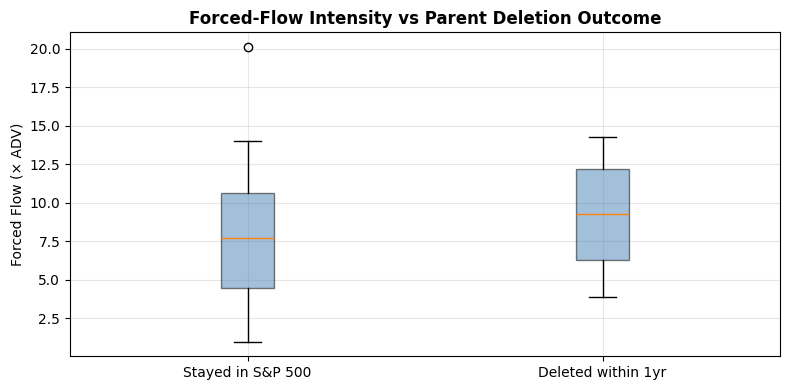

Deleted (n=4): mean forced flow = 9.2×
Stayed  (n=21):  mean forced flow = 8.3×
t=0.35  p=0.728


In [20]:
# Does forced-flow signal correlate with parent deletion?
if 'forced_flow_adv' in events.columns and events['deleted_within_1yr'].notna().any():
    del_yes = events[events['deleted_within_1yr'] == True]['forced_flow_adv'].dropna()
    del_no  = events[events['deleted_within_1yr'] == False]['forced_flow_adv'].dropna()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot([del_no, del_yes], labels=['Stayed in S&P 500', 'Deleted within 1yr'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_ylabel('Forced Flow (× ADV)')
    ax.set_title('Forced-Flow Intensity vs Parent Deletion Outcome', fontweight='bold')
    plt.tight_layout()
    plt.show()

    if len(del_yes) > 1 and len(del_no) > 1:
        t_stat, p_val = stats.ttest_ind(del_yes, del_no)
        print(f'Deleted (n={len(del_yes)}): mean forced flow = {del_yes.mean():.1f}×')
        print(f'Stayed  (n={len(del_no)}):  mean forced flow = {del_no.mean():.1f}×')
        print(f't={t_stat:.2f}  p={p_val:.3f}')

## 10. Summary — Key Findings

In [21]:
print('=' * 65)
print('DATA COVERAGE')
print('=' * 65)
print(f'  Spinoff events (Bloomberg, 2020–2025):      {len(events)}')
print(f'  Spinoff children with CRSP price data:      {all_cw["child_ticker"].nunique() if len(all_cw) else 0} / {len(events)}')
print(f'  Excluded children (forced-selling targets):  '
      f'{(events["inclusion_status"]=="excluded").sum()} / {len(events)}')
print(f'  Immediately included children:               '
      f'{(events["inclusion_status"]=="immediately included").sum()} / {len(events)}')
if passive_aum is not None:
    lat = passive_aum.sort_values('date').iloc[-1]
    print(f'  Passive AUM (latest):                       '
          f'${lat["total_aum_billions"]:.0f}B ({lat["date"].strftime("%b %Y")})')

print()
print('=' * 65)
print('FORCED-FLOW FEATURE')
print('=' * 65)
if 'forced_flow_adv' in events.columns:
    ff = events['forced_flow_adv'].dropna()
    ff_usd = events['forced_flow_usd'].dropna() / 1e9
    print(f'  Median:  {ff.median():.1f}× ADV  |  ${ff_usd.median():.1f}B')
    print(f'  Mean:    {ff.mean():.1f}× ADV  |  ${ff_usd.mean():.1f}B')
    top = events.loc[ff.idxmax()]
    print(f'  Max:     {ff.max():.1f}× ADV  ({top["parent_ticker"]} → {top["spinoff_ticker"]})')
    print(f'  >10× ADV: {(ff >= 10).sum()} events   >5× ADV: {(ff >= 5).sum()} events')

print()
print('=' * 65)
print('SHORT TRADE RETURNS (EXCLUDED CHILDREN)')
print('=' * 65)
if len(all_cw) and 'short_pnl_21d' in car_df.columns:
    for h in [5, 10, 21, 63]:
        col = f'short_pnl_{h}d'
        excl = car_df[car_df['inclusion_status'] == 'excluded'][col].dropna()
        incl = car_df[car_df['inclusion_status'] == 'immediately included'][col].dropna()
        if len(excl) > 0:
            t, p = stats.ttest_1samp(excl, 0)
            incl_mean = incl.mean() if len(incl) > 0 else np.nan
            print(f'  t={h:2d}d  excluded: {excl.mean()*100:+.2f}%  '
                  f'included: {incl_mean*100 if pd.notna(incl_mean) else np.nan:+.2f}%  '
                  f'(t={t:.2f}, p={p:.3f}, n={len(excl)})')

print()
print('=' * 65)
print('CANDIDATE FEATURES FOR SIGNAL MODEL')
print('=' * 65)
features = [
    ('forced_flow_adv',  'Forced Flow (× ADV)',       'PRIMARY — passive AUM × parent weight ÷ child ADV'),
    ('forced_flow_usd',  'Forced Flow ($)',            'Raw dollar selling pressure on child'),
    ('inclusion_status', 'Child SP500 Status',         'Gate: excluded only → forced selling applies'),
    ('deleted_within_1yr','Parent Deletion Flag',      'If parent exits, hedge is also dislocated'),
    ('announce_lag_days','Announce → Effective (days)','Longer = more pre-positioning by arb funds'),
    ('parent_index_weight','Parent Index Weight',      'Scales forced-flow magnitude'),
]
for col, name, desc in features:
    avail = events[col].notna().sum() if col in events.columns else 0
    print(f'  {name:<28s}  {avail:2d}/30  {desc}')

print()
print('NEXT STEPS')
print('  1. Deletion probability model: logistic regression on parent fundamentals')
print('  2. Composite signal: forced_flow_adv × (1 − deletion_prob_parent)')
print('  3. Backtest: short child at t=0 close, long SPY futures, size by signal')
print('  4. Exits: child added to S&P 500, 21/42/63-day stops, stop-loss at +10%')

DATA COVERAGE
  Spinoff events (Bloomberg, 2020–2025):      30
  Spinoff children with CRSP price data:      21 / 30
  Excluded children (forced-selling targets):  17 / 30
  Immediately included children:               13 / 30
  Passive AUM (latest):                       $4401B (Mar 2026)

FORCED-FLOW FEATURE
  Median:  7.7× ADV  |  $1.5B
  Mean:    9.7× ADV  |  $3.7B
  Max:     46.5× ADV  (LEN/B → MRP)
  >10× ADV: 12 events   >5× ADV: 22 events

SHORT TRADE RETURNS (EXCLUDED CHILDREN)
  t= 5d  excluded: +1.30%  included: +10.77%  (t=0.22, p=0.832, n=9)
  t=10d  excluded: +4.05%  included: +8.54%  (t=0.64, p=0.537, n=9)
  t=21d  excluded: +1.78%  included: +5.03%  (t=0.27, p=0.795, n=9)
  t=63d  excluded: -1.25%  included: +3.72%  (t=-0.13, p=0.901, n=9)

CANDIDATE FEATURES FOR SIGNAL MODEL
  Forced Flow (× ADV)           30/30  PRIMARY — passive AUM × parent weight ÷ child ADV
  Forced Flow ($)               30/30  Raw dollar selling pressure on child
  Child SP500 Status            